In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import numpy as np
import os
import zipfile
import cv2
import matplotlib.pyplot as plt


In [ ]:
zip_path = '/content/dataset2.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'File berhasil diekstrak ke {extract_path}')

File berhasil diekstrak ke /content/


In [ ]:
def canny_edge_detection(image_array):
    gray_image = cv2.cvtColor(image_array.astype('float32'), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(np.uint8(gray_image*255), threshold1=100, threshold2=200)
    return edges

In [ ]:
def show_images(original_img, segmented_img):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_img)
    axes[0].set_title("Gambar asli")
    axes[0].axis("off")

    axes[1].imshow(segmented_img, cmap='gray')
    axes[1].set_title("Canny Edge Segmentation")
    axes[1].axis("off")

    plt.show()

In [ ]:
image_dir = '/content/dataset2'

images = []
labels = []

data_gen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0

        label = int(filename.split('.')[0])

        # Augmentasi gambar
        img_array = np.expand_dims(img_array, axis=0)
        augmented_images = data_gen.flow(img_array, batch_size=1)

        for _ in range(3):
            aug_img = next(augmented_images)[0]
            images.append(aug_img)
            labels.append(label)

        images.append(img_array[0])
        labels.append(label)

X = np.array(images)
y = np.array(labels)

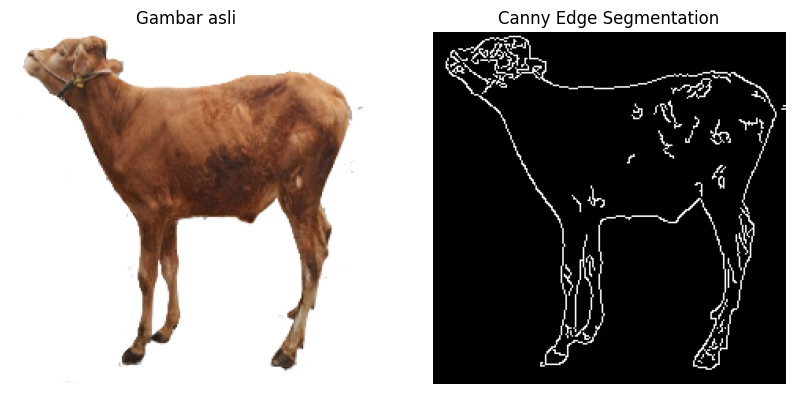

In [ ]:
def select_image_by_path(image_path):
    if os.path.exists(image_path):
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        return img_array
    else:
        print(f"Gambar dengan path {image_path} tidak ditemukan!")
        return None

image_path = '/content/dataset2/180.jpg'
selected_image = select_image_by_path(image_path)

if selected_image is not None:
    segmented_image = canny_edge_detection(selected_image)
    show_images(selected_image, segmented_image)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load ResNet50 sebagai feature extractor
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)  # Dropout lebih tinggi untuk mencegah overfitting
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='linear')(x)  # Regresi

# Definisikan model
model = Model(inputs=base_model.input, outputs=output)

# Compile dengan Huber loss dan ReduceLROnPlateau
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)


# Print Model Summary
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 24,801,153 (94.61 MB)

 Trainable params: 1,213,441 (4.63 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
import tensorflow as tf
import time

# Fungsi custom RMSE
def rmse(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)  # Konversi y_true ke float32
    return tf.sqrt(tf.keras.backend.mean(tf.square(y_true - y_pred)))

# Callback untuk mengurangi learning rate saat training stagnan
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Callback untuk menyimpan model terbaik berdasarkan loss terkecil
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Compile model dengan RMSE sebagai metrik tambahan
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', rmse]
)

# Mulai hitung waktu training
start_time = time.time()

# Training model
history = model.fit(
    X, y.astype('float32'),  # Pastikan y bertipe float32
    epochs=750,
    batch_size=32,
    validation_data=(X_val, y_val.astype('float32')) if 'X_val' in locals() else None,
    callbacks=[checkpoint, reduce_lr]
)

# Selesai hitung waktu training
end_time = time.time()
training_time = end_time - start_time
print(f"Waktu training: {training_time:.2f} detik")


Epoch 1/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 265590.6875 - mae: 460.4886 - rmse: 513.2015  
Epoch 1: loss improved from inf to 239100.12500, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 7s/step - loss: 256760.5000 - mae: 452.6589 - rmse: 504.1133 - learning_rate: 0.0010
Epoch 2/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 235317.6562 - mae: 430.5298 - rmse: 485.0988  
Epoch 2: loss improved from 239100.12500 to 234807.64062, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - loss: 235147.6562 - mae: 431.0960 - rmse: 484.9316 - learning_rate: 0.0010
Epoch 3/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 220025.1406 - mae: 419.7620 - rmse: 468.7073  
Epoch 3: loss improved from 234807.64062 to 228779.28125, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 7s/step - loss: 222943.1875 - mae: 421.5755 - rmse: 471.7866 - learning_rate: 0.0010
Epoch 4/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 213986.8125 - mae: 408.4995 - rmse: 462.5396
Epoch 4: loss improved from 228779.28125 to 218883.62500, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 7s/step - loss: 215619.0781 - mae: 410.1227 - rmse: 464.2462 - learning_rate: 0.0010
Epoch 5/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 179058.5625 - mae: 380.0012 - rmse: 420.9293  
Epoch 5: loss improved from 218883.62500 to 203421.26562, saving model to best_model.h5


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - loss: 36424.0078 - mae: 148.8679 - rmse: 234.1467 - learning_rate: 1.0000e-06
Epoch 251/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 40824.1484 - mae: 162.6958 - rmse: 228.7836  
Epoch 251: loss did not improve from 33463.15625
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - loss: 40603.3594 - mae: 161.6869 - rmse: 229.2067 - learning_rate: 1.0000e-06
Epoch 252/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 30821.9375 - mae: 138.2585 - rmse: 220.9878
Epoch 252: loss did not improve from 33463.15625
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step - loss: 32165.2949 - mae: 140.5759 - rmse: 223.8147 - learning_rate: 1.0000e-06
Epoch 253/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 38284.3984 - mae: 160.9737 - rmse: 234.3030  
Epoch 253: loss did not improve from 33463.15625
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - loss: 37354.0703 - mae: 158.1645 - rmse: 233.3853 - learning_rate: 1.0000e-06
Epoch 254/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 40186.2734 - mae:

2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - loss: 28408.7168 - mae: 136.5970 - rmse: 211.9725 - learning_rate: 1.0000e-06
Epoch 271/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 41579.1562 - mae: 162.3105 - rmse: 244.1064  
Epoch 271: loss did not improve from 32714.79297
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - loss: 39786.5703 - mae: 159.2947 - rmse: 239.2748 - learning_rate: 1.0000e-06
Epoch 272/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 41960.3438 - mae: 161.0678 - rmse: 241.3336  
Epoch 272: loss did not improve from 32714.79297
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - loss: 41130.9961 - mae: 160.1048 - rmse: 238.1187 - learning_rate: 1.0000e-06
Epoch 273/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 43380.3477 - mae: 161.9333 - rmse: 246.2023
Epoch 273: loss did not improve from 32714.79297
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 6s/step - loss: 41352.5430 - mae: 158.1559 - rmse: 239.8115 - learning_rate: 1.0000e-06
Epoch 274/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 42881.6328 - mae:

2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - loss: 36580.7031 - mae: 151.0384 - rmse: 239.1198 - learning_rate: 1.0000e-06
Epoch 376/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 41748.6797 - mae: 156.2242 - rmse: 234.4395
Epoch 376: loss did not improve from 31983.25000
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - loss: 40922.8242 - mae: 155.8427 - rmse: 232.2755 - learning_rate: 1.0000e-06
Epoch 377/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 38945.0312 - mae: 156.5084 - rmse: 244.3779  
Epoch 377: loss did not improve from 31983.25000
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - loss: 37760.9883 - mae: 153.8993 - rmse: 238.6737 - learning_rate: 1.0000e-06
Epoch 378/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 39260.6523 - mae: 163.5526 - rmse: 236.0747  
Epoch 378: loss did not improve from 31983.25000
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - loss: 38145.5391 - mae: 159.6624 - rmse: 232.9301 - learning_rate: 1.0000e-06
Epoch 379/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 47190.1562 - mae:

2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - loss: 32521.6953 - mae: 137.4835 - rmse: 231.3534 - learning_rate: 1.0000e-06
Epoch 630/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 35877.8516 - mae: 150.5795 - rmse: 214.7404
Epoch 630: loss did not improve from 31792.31641
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - loss: 36740.4141 - mae: 151.3848 - rmse: 219.0873 - learning_rate: 1.0000e-06
Epoch 631/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 49202.2109 - mae: 173.6073 - rmse: 242.6761  
Epoch 631: loss did not improve from 31792.31641
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - loss: 47449.0977 - mae: 169.5826 - rmse: 237.7354 - learning_rate: 1.0000e-06
Epoch 632/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 34324.5703 - mae: 145.4142 - rmse: 223.2282
Epoch 632: loss did not improve from 31792.31641
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - loss: 34880.7617 - mae: 146.6254 - rmse: 224.7137 - learning_rate: 1.0000e-06
Epoch 633/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 33576.8555 - mae: 1

2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - loss: 31083.2324 - mae: 140.1015 - rmse: 227.2797 - learning_rate: 1.0000e-06
Epoch 735/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 32326.0391 - mae: 144.1529 - rmse: 229.6613  
Epoch 735: loss did not improve from 31540.59570
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - loss: 32915.1328 - mae: 144.1988 - rmse: 230.0137 - learning_rate: 1.0000e-06
Epoch 736/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 35006.7344 - mae: 146.9320 - rmse: 218.5129  
Epoch 736: loss did not improve from 31540.59570
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - loss: 35640.1445 - mae: 148.1073 - rmse: 222.4134 - learning_rate: 1.0000e-06
Epoch 737/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 42224.4219 - mae: 161.9885 - rmse: 239.0610  
Epoch 737: loss did not improve from 31540.59570
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - loss: 40277.7109 - mae: 158.6553 - rmse: 234.9259 - learning_rate: 1.0000e-06
Epoch 738/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 25122.4336 - ma

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


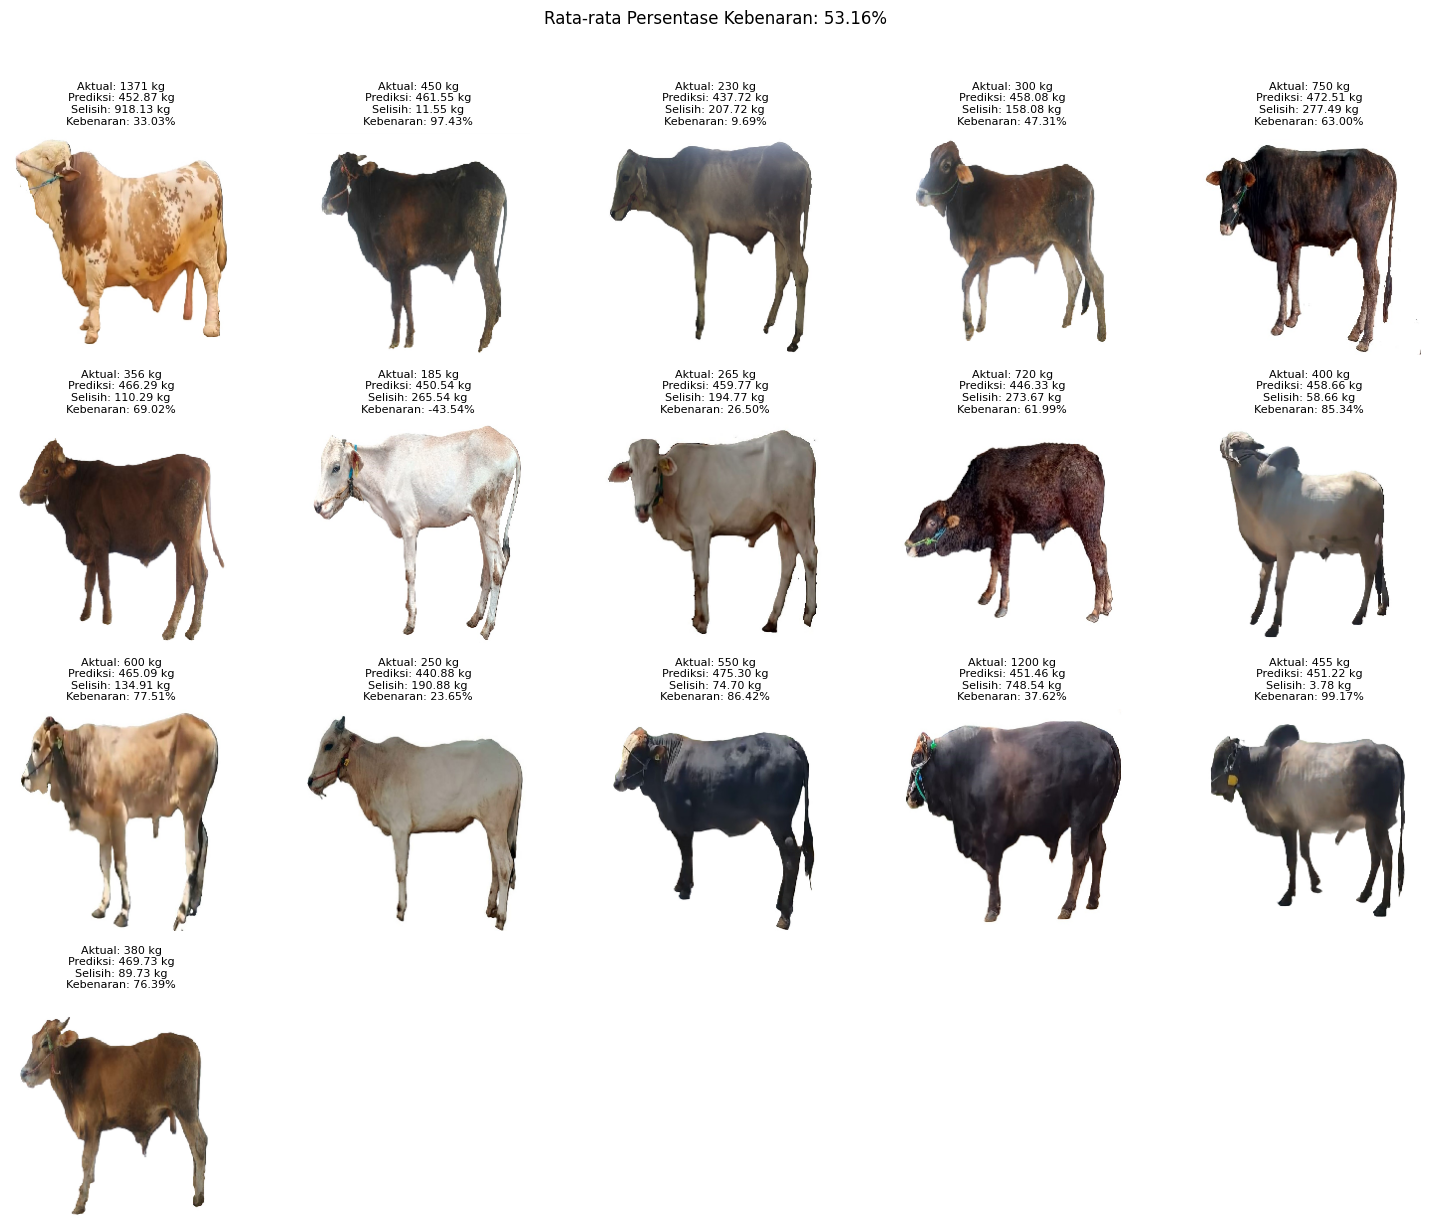

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/test_dataset.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/test_dataset'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)
num_images = len(X)

cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


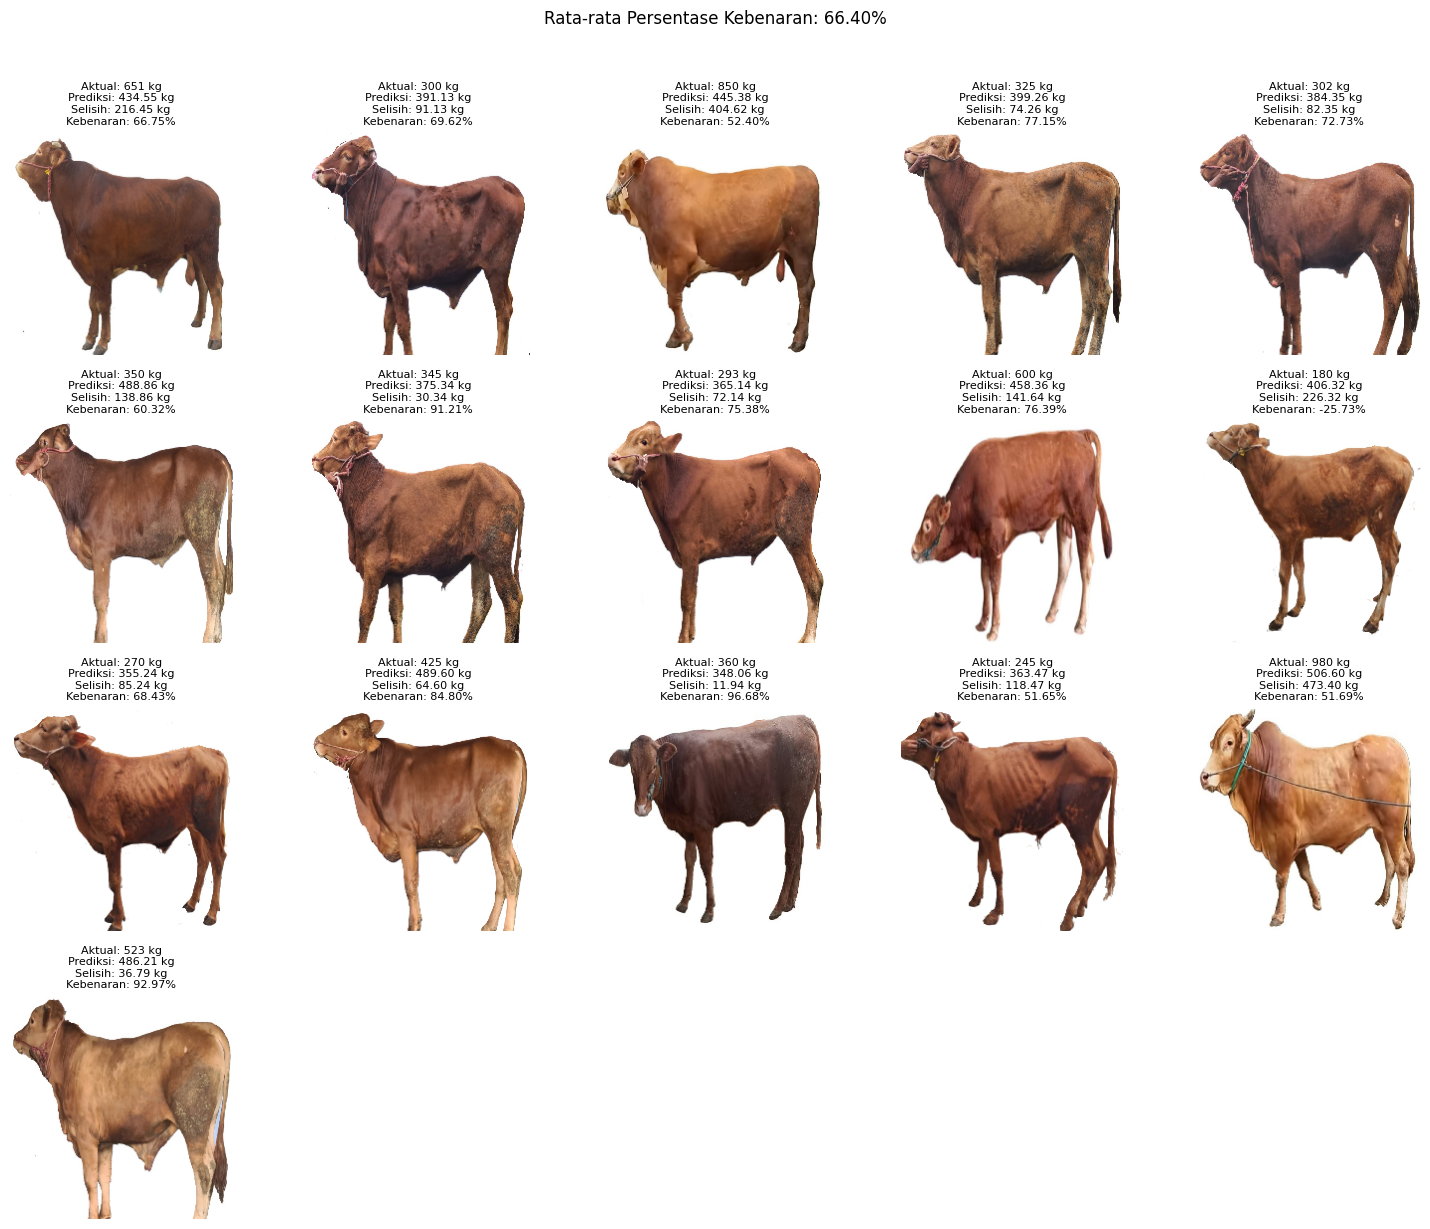

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/dataset2.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/dataset2'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        # Memuat gambar
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)

num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


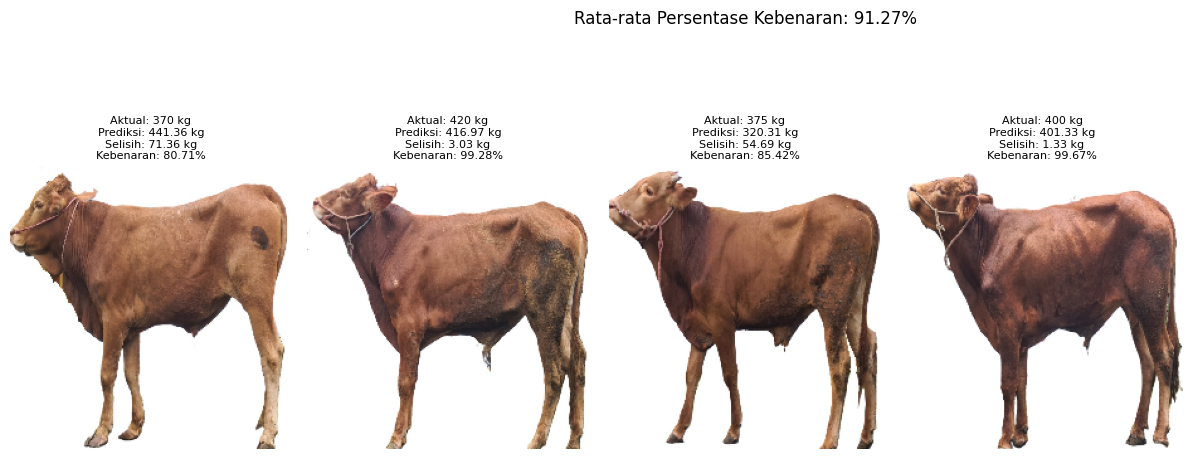

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/test.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/test'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        # Memuat gambar
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)

num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


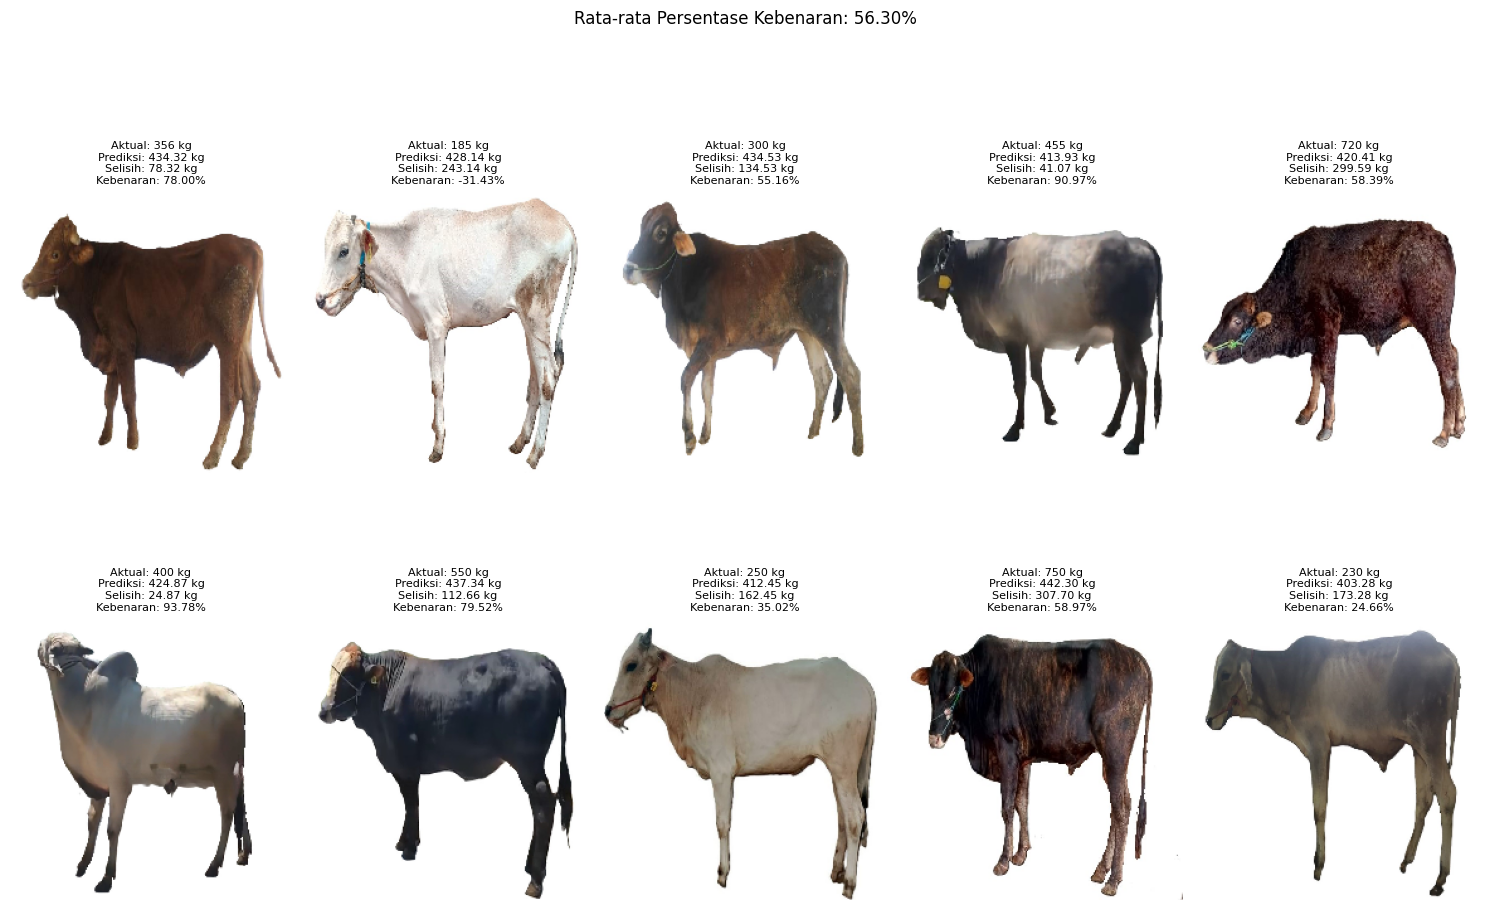

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/test_dataset.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/test_dataset'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)
num_images = len(X)

cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

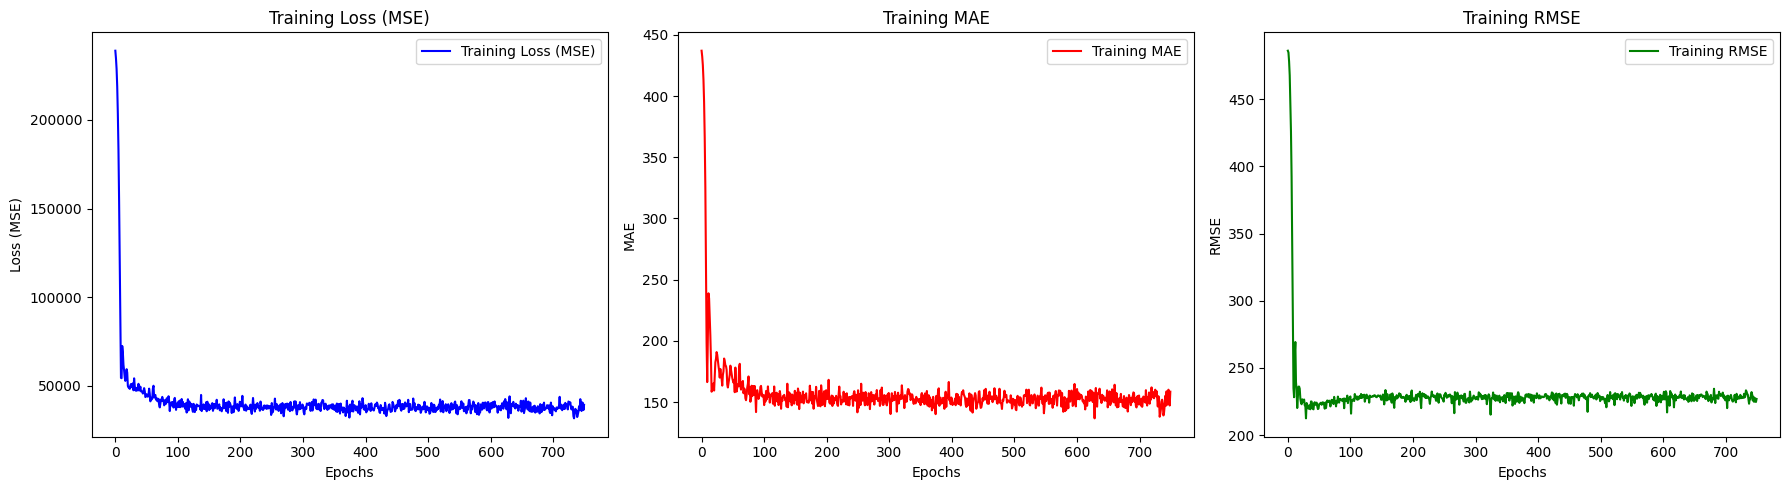

In [ ]:
plt.figure(figsize=(18, 5))

# Plot Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss (MSE)')
plt.legend()

# Plot Mean Absolute Error (MAE)
plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE', color='red')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training MAE')
plt.legend()

# Plot Root Mean Squared Error (RMSE)
plt.subplot(1, 3, 3)
plt.plot(history.history['rmse'], label='Training RMSE', color='green')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Training RMSE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Ambil nilai MAE dan RMSE dari history
mae_values = history.history['mae']
rmse_values = history.history['rmse']

min_mae_index = mae_values.index(min(mae_values))

min_mae = mae_values[min_mae_index]
corresponding_rmse = rmse_values[min_mae_index]

print(f"MAE terkecil: {min_mae:.4f} pada epoch {min_mae_index + 1}")
print(f"RMSE pada epoch yang sama: {corresponding_rmse:.4f}")


MAE terkecil: 136.7536 pada epoch 629
RMSE pada epoch yang sama: 232.5229


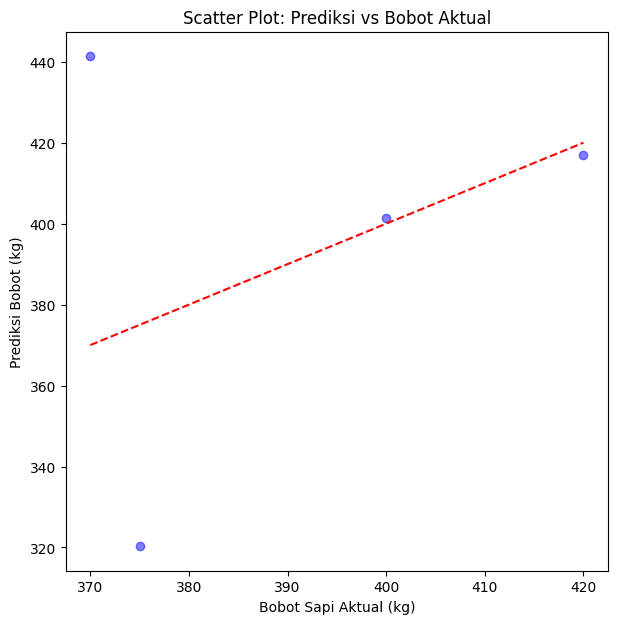

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y, prediksi_bobot, alpha=0.5, color='blue')
plt.plot([min(y), max(y)], [min(y), max(y)], '--', color='red')
plt.xlabel("Bobot Sapi Aktual (kg)")
plt.ylabel("Prediksi Bobot (kg)")
plt.title("Scatter Plot: Prediksi vs Bobot Aktual")
plt.show()
